# Model Comparison: YOLOv8m vs MobileNet

This notebook compares the performance of two face mask detection models:
- **YOLOv8m v2**: Object detection model (face_mask_detection_yolov8m_v2_best.pt)
- **MobileNet**: Classification model (face_mask_mobilenet_best.h5)

In [5]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [6]:
# Define paths
BASE_DIR = Path('/home/khoanguyen/workspace/UIT/face_mask_detection')
YOLOV8_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolov8m_v2_best.pt'
MOBILENET_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_mobilenet_best.h5'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

print(f"YOLOv8 model exists: {YOLOV8_MODEL_PATH.exists()}")
print(f"MobileNet model exists: {MOBILENET_MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

YOLOv8 model exists: True
MobileNet model exists: True
Test images directory exists: True
Test labels directory exists: True


In [7]:
# Load models
print("Loading YOLOv8 model...")
yolo_model = YOLO(str(YOLOV8_MODEL_PATH))

print("Loading MobileNet model...")
mobilenet_model = keras.models.load_model(str(MOBILENET_MODEL_PATH), compile=False)

print("Models loaded successfully!")

Loading YOLOv8 model...
Loading MobileNet model...
Models loaded successfully!


In [8]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

print("Sample test image paths:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 86 test images
Sample test image paths:
  maksssksksss119.png
  maksssksksss125.png
  maksssksksss133.png


## YOLOv8 Model Evaluation

In [9]:
# YOLOv8 Predictions
print("Running YOLOv8 predictions on test set...")

yolo_y_true = []
yolo_y_pred = []
yolo_confidences = []

for img_path in tqdm(test_images):
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Run prediction
    results = yolo_model(str(img_path), verbose=False)
    
    # Extract predictions
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                yolo_y_pred.append(pred_class)
                yolo_confidences.append(confidence)
    
    # Extract ground truth (one label per detection)
    for gt_class, _, _, _, _ in gt_labels:
        yolo_y_true.append(gt_class)

# Handle case where number of predictions doesn't match ground truth
min_len = min(len(yolo_y_true), len(yolo_y_pred))
yolo_y_true = yolo_y_true[:min_len]
yolo_y_pred = yolo_y_pred[:min_len]
yolo_confidences = yolo_confidences[:min_len]

print(f"YOLOv8 - Total predictions: {len(yolo_y_pred)}")
print(f"YOLOv8 - Total ground truth: {len(yolo_y_true)}")

Running YOLOv8 predictions on test set...


100%|██████████| 86/86 [00:03<00:00, 24.17it/s]

YOLOv8 - Total predictions: 386
YOLOv8 - Total ground truth: 386


In [10]:
# Calculate YOLOv8 metrics
yolo_accuracy = accuracy_score(yolo_y_true, yolo_y_pred)
yolo_precision = precision_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_recall = recall_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_f1 = f1_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)

# Per-class metrics
yolo_precision_per_class = precision_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_recall_per_class = recall_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_f1_per_class = f1_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)

print("YOLOv8 Model Metrics:")
print(f"  Accuracy:  {yolo_accuracy:.4f}")
print(f"  Precision: {yolo_precision:.4f}")
print(f"  Recall:    {yolo_recall:.4f}")
print(f"  F1-Score:  {yolo_f1:.4f}")
print(f"  Avg Confidence: {np.mean(yolo_confidences):.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(yolo_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {yolo_precision_per_class[i]:.4f}")
        print(f"    Recall:    {yolo_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {yolo_f1_per_class[i]:.4f}")

YOLOv8 Model Metrics:
  Accuracy:  0.7513
  Precision: 0.7533
  Recall:    0.7513
  F1-Score:  0.7522
  Avg Confidence: 0.7579

Per-class metrics:
  With Mask:
    Precision: 0.8558
    Recall:    0.8532
    F1-Score:  0.8545
  Without Mask:
    Precision: 0.1765
    Recall:    0.1875
    F1-Score:  0.1818
  Mask Weared Incorrect:
    Precision: 0.2222
    Recall:    0.1818
    F1-Score:  0.2000


## MobileNet Model Evaluation

MobileNet is a classification model, so we'll use YOLOv8's detections as a face detector and then classify each detected face.

In [12]:
# MobileNet Predictions
print("Running MobileNet predictions on test set...")

mobilenet_y_true = []
mobilenet_y_pred = []
mobilenet_confidences = []

# Image size for MobileNet (need to check what size it was trained on)
IMG_SIZE = 192  # MobileNet was trained with 192x192 input

for img_path in tqdm(test_images):
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Read image
    img = cv2.imread(str(img_path))
    img_h, img_w = img.shape[:2]
    
    # Use YOLOv8 as face detector
    results = yolo_model(str(img_path), verbose=False)
    
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                # Get bounding box coordinates
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                
                # Crop face region
                face = img[y1:y2, x1:x2]
                if face.size == 0:
                    continue
                
                # Preprocess for MobileNet
                face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
                face_normalized = face_rgb / 255.0
                face_batch = np.expand_dims(face_normalized, axis=0)
                
                # Predict
                pred = mobilenet_model.predict(face_batch, verbose=0)
                pred_class = np.argmax(pred[0])
                confidence = np.max(pred[0])
                
                mobilenet_y_pred.append(pred_class)
                mobilenet_confidences.append(confidence)
    
    # Extract ground truth
    for gt_class, _, _, _, _ in gt_labels:
        mobilenet_y_true.append(gt_class)

# Align predictions and ground truth
min_len = min(len(mobilenet_y_true), len(mobilenet_y_pred))
mobilenet_y_true = mobilenet_y_true[:min_len]
mobilenet_y_pred = mobilenet_y_pred[:min_len]
mobilenet_confidences = mobilenet_confidences[:min_len]

print(f"MobileNet - Total predictions: {len(mobilenet_y_pred)}")
print(f"MobileNet - Total ground truth: {len(mobilenet_y_true)}")

Running MobileNet predictions on test set...


  0%|          | 0/86 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1771301841.477803   13672 service.cc:152] XLA service 0x7fd9b80031a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771301841.477837   13672 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
I0000 00:00:1771301841.928549   13672 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771301848.226810   13672 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 86/86 [00:32<00:00,  2.67it/s]

MobileNet - Total predictions: 386
MobileNet - Total ground truth: 386


In [13]:
# Calculate MobileNet metrics
mobilenet_accuracy = accuracy_score(mobilenet_y_true, mobilenet_y_pred)
mobilenet_precision = precision_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_recall = recall_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_f1 = f1_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)

# Per-class metrics
mobilenet_precision_per_class = precision_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_recall_per_class = recall_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_f1_per_class = f1_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)

print("MobileNet Model Metrics:")
print(f"  Accuracy:  {mobilenet_accuracy:.4f}")
print(f"  Precision: {mobilenet_precision:.4f}")
print(f"  Recall:    {mobilenet_recall:.4f}")
print(f"  F1-Score:  {mobilenet_f1:.4f}")
print(f"  Avg Confidence: {np.mean(mobilenet_confidences):.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(mobilenet_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {mobilenet_precision_per_class[i]:.4f}")
        print(f"    Recall:    {mobilenet_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {mobilenet_f1_per_class[i]:.4f}")

MobileNet Model Metrics:
  Accuracy:  0.6399
  Precision: 0.7483
  Recall:    0.6399
  F1-Score:  0.6819
  Avg Confidence: 1.5556

Per-class metrics:
  With Mask:
    Precision: 0.8524
    Recall:    0.7064
    F1-Score:  0.7726
  Without Mask:
    Precision: 0.1339
    Recall:    0.3125
    F1-Score:  0.1875
  Mask Weared Incorrect:
    Precision: 0.3333
    Recall:    0.0909
    F1-Score:  0.1429


## Model Comparison

In [14]:
# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Confidence'],
    'YOLOv8m v2': [
        f'{yolo_accuracy:.4f}',
        f'{yolo_precision:.4f}',
        f'{yolo_recall:.4f}',
        f'{yolo_f1:.4f}',
        f'{np.mean(yolo_confidences):.4f}'
    ],
    'MobileNet': [
        f'{mobilenet_accuracy:.4f}',
        f'{mobilenet_precision:.4f}',
        f'{mobilenet_recall:.4f}',
        f'{mobilenet_f1:.4f}',
        f'{np.mean(mobilenet_confidences):.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("OVERALL MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)


OVERALL MODEL COMPARISON
        Metric YOLOv8m v2 MobileNet
      Accuracy     0.7513    0.6399
     Precision     0.7533    0.7483
        Recall     0.7513    0.6399
      F1-Score     0.7522    0.6819
Avg Confidence     0.7579    1.5556


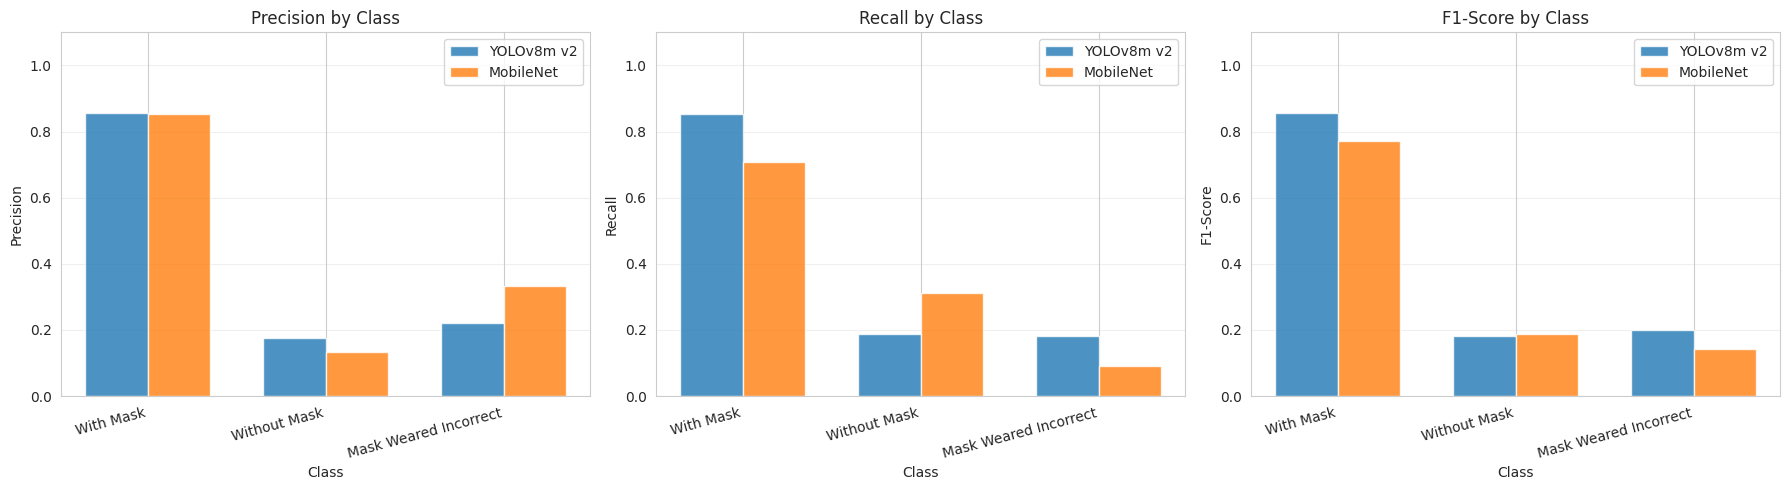

In [15]:
# Per-class comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
yolo_metrics = [yolo_precision_per_class, yolo_recall_per_class, yolo_f1_per_class]
mobilenet_metrics = [mobilenet_precision_per_class, mobilenet_recall_per_class, mobilenet_f1_per_class]

for idx, (metric_name, yolo_vals, mobilenet_vals) in enumerate(zip(metrics, yolo_metrics, mobilenet_metrics)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.35
    
    # Ensure all classes are represented
    yolo_plot = np.zeros(len(CLASS_NAMES))
    mobilenet_plot = np.zeros(len(CLASS_NAMES))
    
    for i in range(len(CLASS_NAMES)):
        if i < len(yolo_vals):
            yolo_plot[i] = yolo_vals[i]
        if i < len(mobilenet_vals):
            mobilenet_plot[i] = mobilenet_vals[i]
    
    ax.bar(x - width/2, yolo_plot, width, label='YOLOv8m v2', alpha=0.8)
    ax.bar(x + width/2, mobilenet_plot, width, label='MobileNet', alpha=0.8)
    
    ax.set_xlabel('Class')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

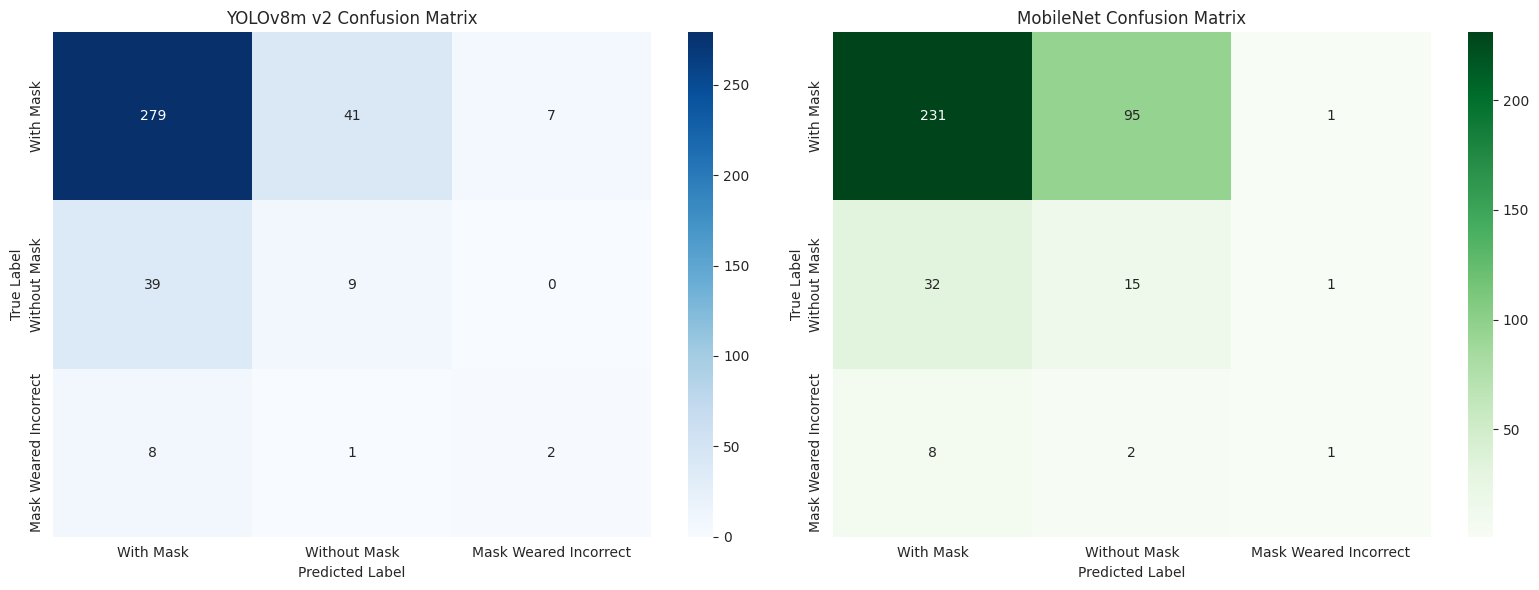

In [16]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# YOLOv8 Confusion Matrix
yolo_cm = confusion_matrix(yolo_y_true, yolo_y_pred)
sns.heatmap(yolo_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('YOLOv8m v2 Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# MobileNet Confusion Matrix
mobilenet_cm = confusion_matrix(mobilenet_y_true, mobilenet_y_pred)
sns.heatmap(mobilenet_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('MobileNet Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

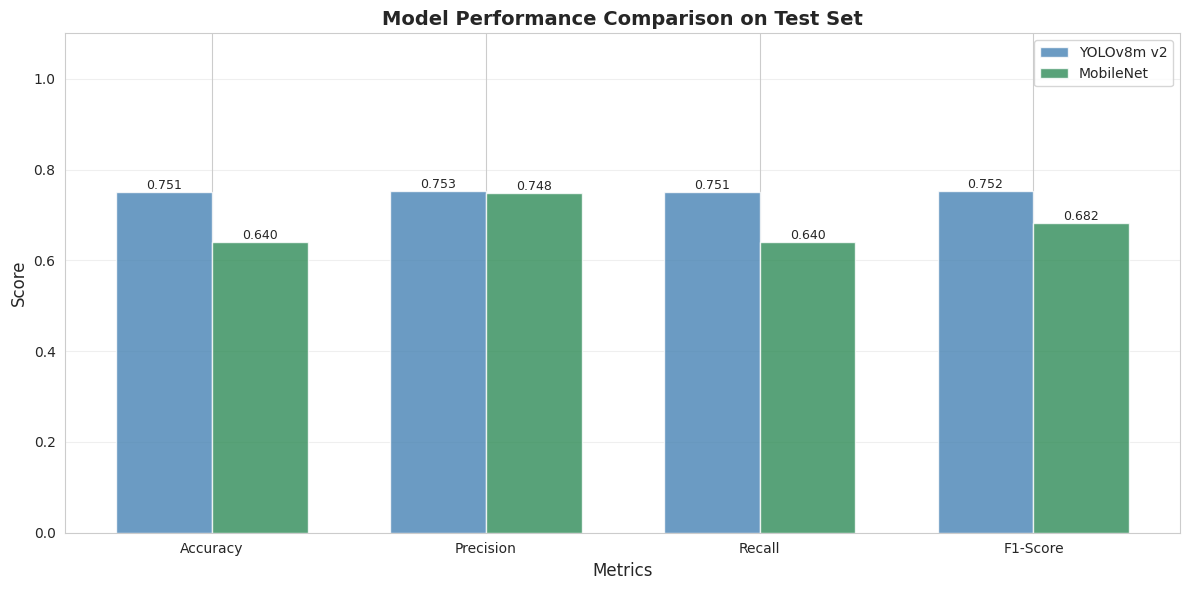

In [17]:
# Overall metrics comparison bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
yolo_values = [yolo_accuracy, yolo_precision, yolo_recall, yolo_f1]
mobilenet_values = [mobilenet_accuracy, mobilenet_precision, mobilenet_recall, mobilenet_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, yolo_values, width, label='YOLOv8m v2', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, mobilenet_values, width, label='MobileNet', alpha=0.8, color='seagreen')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Detailed Classification Reports
print("="*80)
print("YOLOV8M V2 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(yolo_y_true, yolo_y_pred, target_names=CLASS_NAMES, zero_division=0))

print("\n" + "="*80)
print("MOBILENET CLASSIFICATION REPORT")
print("="*80)
print(classification_report(mobilenet_y_true, mobilenet_y_pred, target_names=CLASS_NAMES, zero_division=0))

YOLOV8M V2 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.86      0.85      0.85       327
         Without Mask       0.18      0.19      0.18        48
Mask Weared Incorrect       0.22      0.18      0.20        11

             accuracy                           0.75       386
            macro avg       0.42      0.41      0.41       386
         weighted avg       0.75      0.75      0.75       386


MOBILENET CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.85      0.71      0.77       327
         Without Mask       0.13      0.31      0.19        48
Mask Weared Incorrect       0.33      0.09      0.14        11

             accuracy                           0.64       386
            macro avg       0.44      0.37      0.37       386
         weighted avg       0.75      0.64      0.68       386

